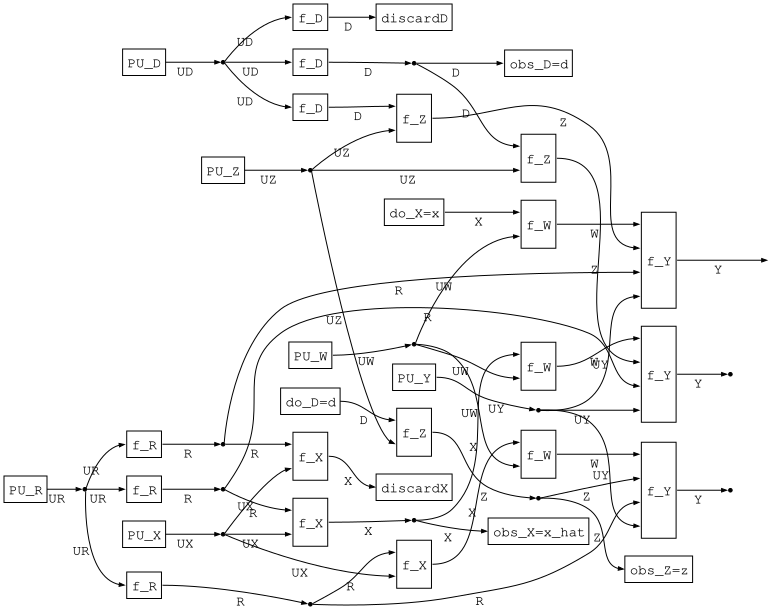

In [2]:


using Catlab
using Catlab.Theories
using Catlab.CategoricalAlgebra
using Catlab.WiringDiagrams
using Catlab.WiringDiagrams.DirectedWiringDiagrams
using Catlab.Programs
using Catlab.Graphics
using Catlab.Graphics: Graphviz, to_graphviz

include("chyp_export.jl")

include("admg_compile.jl")
include("id_cf.jl")
include("simplify_cf.jl")
include("utils.jl")


fig_15b_model = ConfoundedModel(
    [
        :X => :W,
        :W => :Y,
        :D => :Z,
        :Z => :Y
    ],
    Dict(
        :R => [:X,:Y]
    )
)

display_var = Set([:D, :Z, :X, :W, :Y])

base_scm = graph_b_to_scm(fig_15b_model; outputs=display_var)
write_chyp("trace/01_base_scm.chyp", base_scm; name="base")

q1 = CounterfactualQuery(
    :World1, 
    Dict(:X => :x), # Interventions
    Dict{Symbol, Symbol}(),    # No Observations here
    [:Y]              # Output Y
)

q2 = CounterfactualQuery(
    :World2, 
    Dict(),                       # No Interventions
    Dict(:X => :x_hat, :D => :d),            # Observations
    Symbol[]
)

q3 = CounterfactualQuery(
    :World2, 
    Dict(:D => :d),
    Dict(:Z => :z),            # Observations
    Symbol[]
)

queries = [q1, q2, q3]

full_wd = build_multiverse(base_scm, queries)
write_chyp("trace/02_multiverse.chyp", full_wd; name="multi")

draw(add_junctions(full_wd))

# function check_all_inputs_connected(wd::WiringDiagram)
#     in_id = WD.input_id(wd)
#     out_id = WD.output_id(wd)

#     for b in 1:WD.nboxes(wd)
#         
#         for j in 1:length(WD.input_ports(wd, b))
#             ws = WD.in_wires(wd, b, j)
#             if isempty(ws)
#                 println("[MISSING INPUT] box=$b name=$(safe_box_name(wd,b)) inport=$j")
#             end
#         end
#     end
# end

# function check_topo(wd::WiringDiagram)
#     ord = topological_order(wd)
#     all = WD.box_ids(wd)
#     println("topo_len=", length(ord), " all_len=", length(all))
#     missing = setdiff(Set(all), Set(ord))
#     !isempty(missing) && println("missing in topo:", collect(missing))
# end

# check_all_inputs_connected(base_scm)
# check_topo(base_scm)


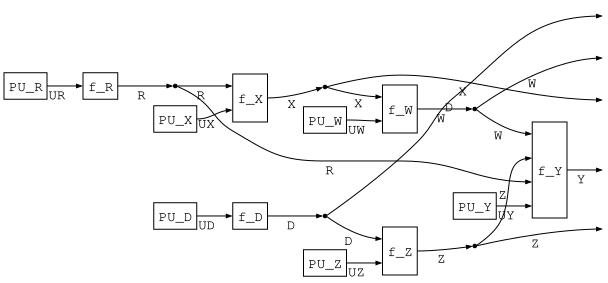

In [2]:
draw(add_junctions(base_scm))

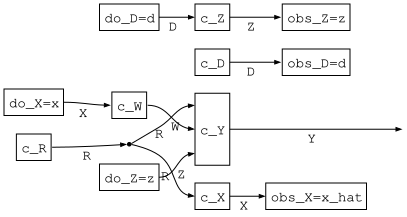

In [3]:
simplified_wd = full_wd
drop_discard_branches!(simplified_wd)
write_chyp("trace/03_simplify1.chyp", simplified_wd; name="simplify1")
merge_identical_deterministic_boxes(simplified_wd)
write_chyp("trace/04_simplify2.chyp", simplified_wd; name="simplify2")
replace_fx_with_cx!(simplified_wd)
write_chyp("trace/05_simplify3.chyp", simplified_wd; name="simplify3")
draw(add_junctions(simplified_wd))

---- Step 4.1 on R-fragment #1 ----
  Fragment 1, var Z, case2 = case2b_rewritten
  Fragment 1, var W, case2 = case2a_do_nothing
  Fragment 1, var X, case1 = case1b_detected
  Fragment 1, var Y, case1 = case1a_do_nothing
---- Step 4.1 on R-fragment #2 ----
  Fragment 2, var D, case1 = case1b_detected
---- Step 4.1 on R-fragment #3 ----
  Fragment 3, var W, case1 = case1a_do_nothing
  Fragment 3, var X, case2 = case2b_rewritten
---- Step 4.1 on R-fragment #4 ----
  Fragment 4, var Z, case1 = case1b_detected
  Fragment 4, var D, case2 = case2b_rewritten
---- Step 4.2: collapsing R-fragment #1 ----
---- Step 4.2: collapsing R-fragment #2 ----
---- Step 4.2: collapsing R-fragment #3 ----
---- Step 4.2: collapsing R-fragment #4 ----


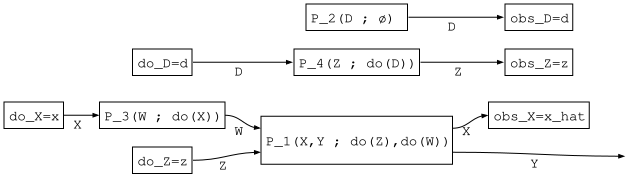

In [4]:
wd = id_cf_step4!(simplified_wd, display_var)
write_chyp("trace/06_id1.chyp", simplified_wd; name="id1")
draw(add_junctions(wd))

In [5]:
directed = [("X","W"), ("W","Y"), ("Z","Y"), ("D","Z")]

res2 = id_cf_step5(
    wd;
    output_vars=["Y"],
    simplify=true,
    rules=Step5RuleConfig(enabled=true, directed_edges=directed),
    display=Step5DisplayConfig(
        symbols=Dict("Y"=>"y","W"=>"w","D"=>"d","Z"=>"z","X"=>"x"),
        value_rename=Dict("x_hat"=>"x'"),
    ),
    data=Step5DataConfig(mode=:interventions, mix_var="D", mix_sym="d^*", mix_target_var="Z", anchor_var="X")
)

res_raw = id_cf_step5(
    wd;
    output_vars=["Y"],
    simplify=true,
    display=Step5DisplayConfig(
        symbols=Dict("Y"=>"y","W"=>"w","D"=>"d","Z"=>"z","X"=>"x"),
        value_rename=Dict("x_hat"=>"x'"),
    ),
    data=Step5DataConfig(mode=:interventions, mix_var="D", mix_sym="d^*", mix_target_var="Z", anchor_var="X")
)
println("raw frac:", res_raw.raw_frac)
println("raw_tex: ", res_raw.raw_tex)
println("simplify:", res2.data_tex)

[rewrite_for_data] WARNING: could not find P(x') in denominator; synthesizing it.
[rewrite_for_data] den = \sum_{w} P(z|do(d))P(x'|do(z,w))P(d)P(w|do(x))
raw frac:CFFrac(CFSum(["w"], CFProd(CFExpr[CFAtom("P(z|do(d))", ["Z"], ["D"], ["z"], ["d"]), CFAtom("P(x',y|do(z,w))", ["X", "Y"], ["Z", "W"], ["x'", "y"], ["z", "w"]), CFAtom("P(d)", ["D"], String[], ["d"], String[]), CFAtom("P(w|do(x))", ["W"], ["X"], ["w"], ["x"])])), CFSum(["w"], CFProd(CFExpr[CFAtom("P(z|do(d))", ["Z"], ["D"], ["z"], ["d"]), CFAtom("P(x'|do(z,w))", ["X"], ["Z", "W"], ["x'"], ["z", "w"]), CFAtom("P(d)", ["D"], String[], ["d"], String[]), CFAtom("P(w|do(x))", ["W"], ["X"], ["w"], ["x"])])))
raw_tex: \frac{\sum_{w} P(z|do(d))P(x',y|do(z,w))P(d)P(w|do(x))}{\sum_{w} P(z|do(d))P(x'|do(z,w))P(d)P(w|do(x))}
simplify:\frac{\sum_{w,d^*} P(z|do(d))P(x',y|do(z,w))P(d^*)P(w|do(x))}{\sum_{d^*} P(x')P(z|do(d^*))P(d^*)}


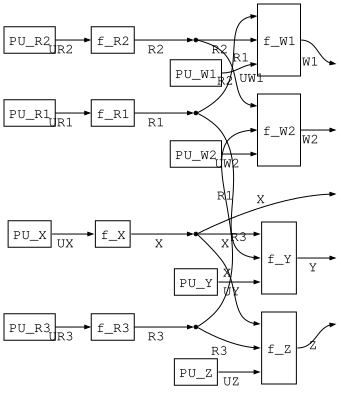

In [6]:
model_2 = ConfoundedModel(
    [
        :X => :Y,
        :X => :Z,
    ],
    Dict(
        :R1 => [:Y,:W1],
        :R2 => [:W1, :W2],
        :R3 => [:W2, :Z],
    )
)
display_var = Set([:X, :Y, :Z, :W1, :W2])
base_scm = graph_b_to_scm(model_2; outputs=display_var)

draw(add_junctions(base_scm))



In [7]:
q1 = CounterfactualQuery(
    :World1, 
    Dict(:X => :doX), # Interventions
    Dict{Symbol, Symbol}(),    # No Observations here
    [:Y,:Z, :W1, :W2]              # Output Y
)
queries = [q1]

full_wd = build_multiverse(base_scm, queries)
full_wd = replace_fx_with_cx!(full_wd)
full_wd = drop_discard_branches!(full_wd)
draw(add_junctions(full_wd))
show_r_fragments(full_wd)

Found 1 R-fragments:
  Fragment 1: c_R3, c_R1, c_R2, c_W1, c_W2, c_Z, c_Y


1-element Vector{Vector{Int64}}:
 [1, 4, 5, 2, 3, 8, 7]

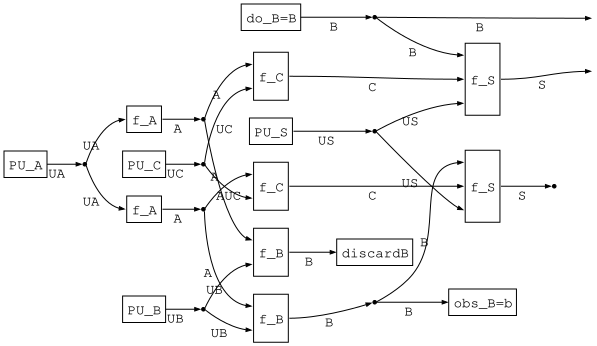

In [8]:
model_party = ConfoundedModel(
  [
    :A => :B,
    :A => :C,
    :B => :S,
    :C => :S,
  ],
  Dict()
)

display_var = Set([:B, :S])

base_scm = graph_b_to_scm(model_party; outputs=display_var)

draw(add_junctions(base_scm))
q_real = CounterfactualQuery(
    :Real, 
    Dict(),              # no interventions in real world
    Dict(:B => :b),           # observe B
    []                 # output
)

q_cf = CounterfactualQuery(
    :CF,
    Dict(:B => :B),    # do(B=1)
    Dict{Symbol, Symbol}(),       # no observations in cf world
    [:B, :S]             # output
)

queries = [q_real, q_cf]

full_wd = build_multiverse(base_scm, queries)
draw(add_junctions(full_wd))




In [9]:

simplified_wd = full_wd
drop_discard_branches!(simplified_wd)
merge_identical_deterministic_boxes(simplified_wd)
replace_fx_with_cx!(simplified_wd)
draw(add_junctions(simplified_wd))
simplified_wd

WiringDiagram([], [:B,:S], 
[ -2 => {inputs},
  -1 => {outputs},
  1 => Box(Symbol("obs_B=b"), [:B], []),
  2 => Box(:c_S, [:C,:B], [:S]),
  3 => Box(Symbol("do_B=B"), [], [:B]),
  4 => Box(:c_C, [:A], [:C]),
  5 => Box(:c_A, [], [:A]),
  6 => Box(:c_B, [:A], [:B]) ],
[ Wire((4,1) => (2,1)),
  Wire((3,1) => (2,2)),
  Wire((5,1) => (4,1)),
  Wire((5,1) => (6,1)),
  Wire((6,1) => (1,1)),
  Wire((3,1) => (-1,1)),
  Wire((2,1) => (-1,2)) ])

---- Step 4.1 on R-fragment #1 ----
  Fragment 1, var B, case2 = case2b_rewritten
  Fragment 1, var S, case1 = case1a_do_nothing
---- Step 4.1 on R-fragment #2 ----
---- Step 4.1 on R-fragment #3 ----
---- Step 4.1 on R-fragment #4 ----
  Fragment 4, var B, case1 = case1b_detected
---- Step 4.2: collapsing R-fragment #1 ----
---- Step 4.2: collapsing R-fragment #2 ----
---- Step 4.2: collapsing R-fragment #3 ----
---- Step 4.2: collapsing R-fragment #4 ----


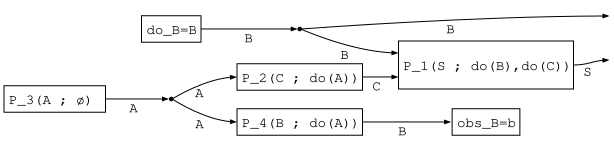

In [10]:
wd = id_cf_step4!(simplified_wd, display_var)
draw(add_junctions(wd))


---- Step 4.1 on R-fragment #1 ----
  Fragment 1, var A, case2 = case2b_rewritten
  Fragment 1, var H, case1 = case1a_do_nothing
---- Step 4.1 on R-fragment #2 ----
  Fragment 2, var A, case1 = case1b_detected
---- Step 4.2: collapsing R-fragment #1 ----
---- Step 4.2: collapsing R-fragment #2 ----


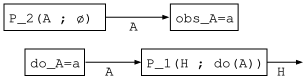

In [11]:
model_fig8 = ConfoundedModel(
    [
        :A => :H
    ],
    Dict()
)
query_fig8 = [
    CounterfactualQuery(
        :w_actual,
        Dict(),
        Dict(:A => :a),
        Symbol[]
    ),

    CounterfactualQuery(
        :w_doA,
        Dict(:A => :a),
        Dict{Symbol, Symbol}(),
        [:H]
    )
]

display_var = Set([:A, :H])

base_scm = graph_b_to_scm(model_fig8; outputs=display_var)
draw(add_junctions(base_scm))

full_wd = build_multiverse(base_scm, query_fig8)
simplified_wd = full_wd
drop_discard_branches!(simplified_wd)
merge_identical_deterministic_boxes(simplified_wd)
replace_fx_with_cx!(simplified_wd)
draw(add_junctions(simplified_wd))
wd = id_cf_step4!(simplified_wd, display_var)
draw(add_junctions(wd))


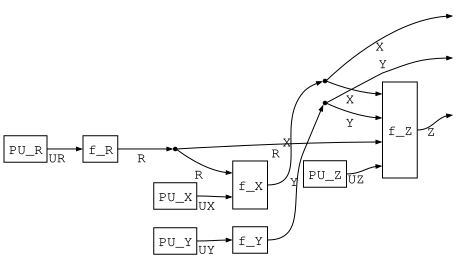

In [12]:
model_fig6b = ConfoundedModel(
    [
        :X => :Z,
        :Y => :Z,
    ],
    Dict(
        :R => [:X, :Z]
    )
)
query_fig6b = [
    CounterfactualQuery(
        :w_doX,
        Dict(:X => :x),
        Dict(:Z => :z),
        [:Y]
    )
]
display_var = Set([:X, :Y, :Z])

base_scm = graph_b_to_scm(model_fig6b; outputs=display_var)
draw(add_junctions(base_scm))

# full_wd = build_multiverse(base_scm, query_fig6b)
# simplified_wd = full_wd
# drop_discard_branches!(simplified_wd)
# merge_identical_deterministic_boxes(simplified_wd)
# replace_fx_with_cx!(simplified_wd)
# draw(add_junctions(simplified_wd))
# wd = id_cf_step4!(simplified_wd, display_var)
# draw(add_junctions(wd))

---- Step 4.1 on R-fragment #1 ----
  Fragment 1, var Y2, case1 = case1a_do_nothing
  Fragment 1, var X, case2 = case2b_rewritten
  Fragment 1, var Y1, case1 = case1a_do_nothing
---- Step 4.1 on R-fragment #2 ----
  Fragment 2, var X, case1 = case1b_detected
---- Step 4.2: collapsing R-fragment #1 ----
---- Step 4.2: collapsing R-fragment #2 ----


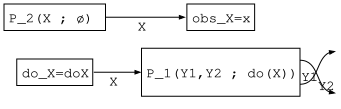

In [13]:
model_cf5 = ConfoundedModel(
    [
        :X => :Y1,
        :X => :Y2
    ],
    Dict(
        :R => [:Y1, :Y2]
    )
)
query_cf5 = [
    CounterfactualQuery(
        :w_actual,
        Dict(),
        Dict(:X => :x),
        Symbol[]
    ),

    CounterfactualQuery(
        :w_doX,
        Dict(:X => :doX),
        Dict{Symbol, Symbol}(),
        [:Y1, :Y2]
    )
]
display_var = Set([:X, :Y1, :Y2])

base_scm = graph_b_to_scm(model_cf5; outputs=display_var)
draw(add_junctions(base_scm))

full_wd = build_multiverse(base_scm, query_cf5)
simplified_wd = full_wd
drop_discard_branches!(simplified_wd)
merge_identical_deterministic_boxes(simplified_wd)
replace_fx_with_cx!(simplified_wd)
draw(add_junctions(simplified_wd))
wd = id_cf_step4!(simplified_wd, display_var)
draw(add_junctions(wd))


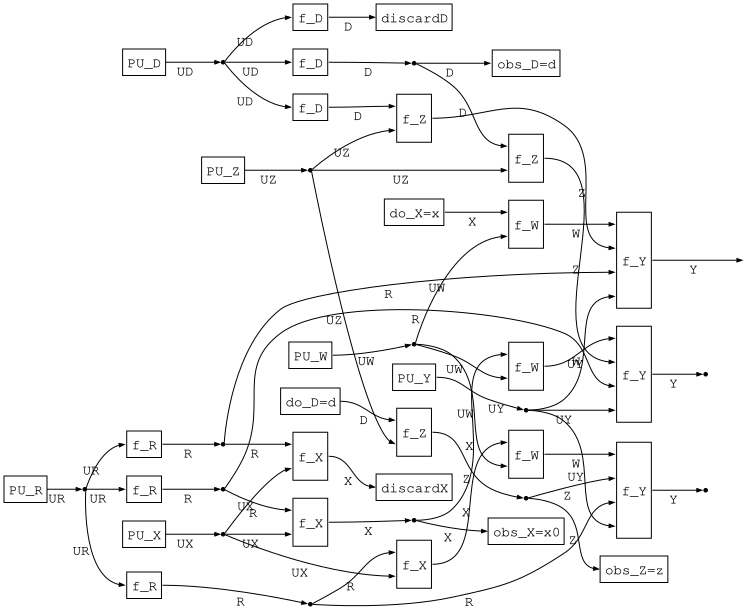

In [ ]:

model = ConfoundedModel(
    [
        :X => :W,
        :W => :Y,
        :D => :Z,
        :Z => :Y
    ],
    Dict(:R => [:X, :Y])
)
base = graph_b_to_scm(model)

queries = [
    CounterfactualQuery(:World1, Dict(:X => :x), Dict{Symbol,Symbol}(), [:Y]),
    CounterfactualQuery(:World2, Dict(), Dict(:X => :x0, :D => :d), Symbol[]),
    CounterfactualQuery(:World3, Dict(:D => :d), Dict(:Z => :z), Symbol[]),
]

wd = build_multiverse(base, queries)
# add_junctions(wd)

In [15]:
    wd = WiringDiagram([], Any[])
    display_vars = Set([:X, :U])

    cR = WD.add_box!(wd, Box(:cR, Any[], Any[:U]))
    cX = WD.add_box!(wd, Box(:cX, Any[:U], Any[:X]))
    WD.add_wire!(wd, (cR,1)=>(cX,1))
    id_cf_step41!(wd, display_vars; verbose=false)


Vector{Int64}[]

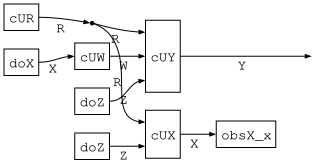

In [16]:

@present CausalR(FreeSymmetricMonoidalCategory) begin
  (R, X, W, Z, Y, D)::Ob

  cUR::Hom(munit(), R)
  cUX::Hom(R ⊗ Z, X)
  cUW::Hom(X, W)
  cUY::Hom(R ⊗ W ⊗ Z, Y)

  doX::Hom(munit(), X)
  doZ::Hom(munit(), Z)

  obsX_x::Hom(X, munit())
end

prog_overall = @program CausalR () begin
  r  = cUR()

  z_for_cx = doZ()
  x_obs = cUX(r, z_for_cx)
  obsX_x(x_obs)

  x_do = doX()
  w    = cUW(x_do)

  z_for_y = doZ()
  y = cUY(r, w, z_for_y)

  return y
end


draw(prog_overall)
draw(add_junctions(prog_overall))

In [18]:
display_var = Set([:Z, :X, :W, :Y])
r_frags = id_cf_step41!(prog_overall, display_var)
# wd = id_cf_step42!(prog_overall, r_frags)

---- Step 4.1 on R-fragment #1 ----
  Fragment 1, var Z, case2 = case2b_rewritten
  Fragment 1, var W, case2 = skip_no_X_input
  Fragment 1, var X, case1 = case1b_detected
  Fragment 1, var Y, case2 = skip_no_X_input
---- Step 4.1 on R-fragment #2 ----
  Fragment 2, var W, case1 = case1a_do_nothing
  Fragment 2, var X, case2 = case2b_rewritten


2-element Vector{Vector{Int64}}:
 [1, 3, 8]
 [6]

In [19]:
model = ConfoundedModel(
    [
        :X => :W,
        :W => :Y,
        :D => :Z,
        :Z => :Y
    ],
    Dict(:R => [:X, :Y])
)
base = graph_b_to_scm(model)

queries = [
    CounterfactualQuery(:World1, Dict(:X => :x), Dict{Symbol,Symbol}(), [:Y]),
    CounterfactualQuery(:World2, Dict(), Dict(:X => :x0, :D => :d), Symbol[]),
    CounterfactualQuery(:World3, Dict(:D => :d), Dict(:Z => :z), Symbol[]),
]

wd = build_multiverse(base, queries)
drop_discard_branches!(wd)
merge_identical_deterministic_boxes(wd)
replace_fx_with_cx!(wd)


WiringDiagram([], [:Y], 
[ -2 => {inputs},
  -1 => {outputs},
  1 => Box(:c_Y, [:R,:W,:Z], [:Y]),
  2 => Box(:c_X, [:R], [:X]),
  3 => Box(Symbol("obs_X=x0"), [:X], []),
  4 => Box(Symbol("obs_D=d"), [:D], []),
  5 => Box(Symbol("do_Z=z"), [], [:Z]),
  6 => Box(Symbol("do_D=d"), [], [:D]),
  7 => Box(:c_D, [], [:D]),
  8 => Box(:c_R, [], [:R]),
  9 => Box(:c_W, [:X], [:W]),
  10 => Box(Symbol("obs_Z=z"), [:Z], []),
  11 => Box(:c_Z, [:D], [:Z]),
  12 => Box(Symbol("do_X=x"), [], [:X]) ],
[ Wire((6,1) => (11,1)),
  Wire((5,1) => (1,3)),
  Wire((2,1) => (3,1)),
  Wire((11,1) => (10,1)),
  Wire((8,1) => (1,1)),
  Wire((9,1) => (1,2)),
  Wire((7,1) => (4,1)),
  Wire((12,1) => (9,1)),
  Wire((8,1) => (2,1)),
  Wire((1,1) => (-1,1)) ])

In [20]:
# rootify test: ADMGModel -> ConfoundedModel -> graph_b_to_scm
admg = ADMGModel(
    [
        :X => :W,
        :W => :Y,
        :D => :Z,
        :Z => :Y,
    ],
    [
        :X => :Y,
    ],
)

expected_rooted = ConfoundedModel(
    [
        :X => :W,
        :W => :Y,
        :D => :Z,
        :Z => :Y,
    ],
    Dict(
        :R1 => [:X, :Y],
    ),
)

rooted = rootify(admg)
@assert rooted.directed == expected_rooted.directed
@assert rooted.latents == expected_rooted.latents

display_vars = Set([:D, :Z, :X, :W, :Y])
wd_from_admg = graph_b_to_scm(admg; outputs=display_vars)
wd_from_rooted = graph_b_to_scm(expected_rooted; outputs=display_vars)

@assert output_ports(wd_from_admg) == output_ports(wd_from_rooted)
@assert length(box_ids(wd_from_admg)) == length(box_ids(wd_from_rooted))
@assert length(wires(wd_from_admg)) == length(wires(wd_from_rooted))

println("input ADMG:")
println(admg)
println()
println("rootified model:")
println(rooted)
println()
println("rootify test passed")


input ADMG:
ADMGModel([:X => :W, :W => :Y, :D => :Z, :Z => :Y], [:X => :Y])

rootified model:
ConfoundedModel([:X => :W, :W => :Y, :D => :Z, :Z => :Y], Dict(:R1 => [:X, :Y]))

rootify test passed


## HEPAR2 import and visualization

Standard HEPAR2 `.net` / `.bif` files describe an observed Bayesian network structure. They do **not** usually mark some nodes as latent.

For this codebase, that means:

- importing HEPAR2 with `read_bn_structure(...)` gives an `ADMGModel` with only `directed` edges and an empty `bidirected` list;
- therefore, **no HEPAR2 node is treated as latent by default**;
- latent variables only appear here if you add `bidirected` edges yourself, and then `rootify(...)` will create synthetic latent roots like `:R1`, `:R2`, ...

So the answer to "which HEPAR2 nodes are latents?" is: **none of them, unless you explicitly model hidden confounding on top of HEPAR2.**

In [21]:
include(joinpath(pwd(), "admg_compile.jl"))
include(joinpath(pwd(), "bn_import.jl"))
include(joinpath(pwd(), "utils.jl"))

hepar2_path = normpath(joinpath(pwd(), "..", "net", "hepar2.net"))
@assert isfile(hepar2_path) "HEPAR2 file not found: $hepar2_path"

hepar2 = read_bn_structure(hepar2_path)
hepar2_model = hepar2.model
hepar2_nodes = hepar2.nodes

println("HEPAR2 nodes: ", length(hepar2_nodes))
println("HEPAR2 directed edges: ", length(hepar2_model.directed))
println("HEPAR2 bidirected edges (hidden confounding): ", length(hepar2_model.bidirected))

# Full SCM expansion is visually dense for HEPAR2.
# Start with a subset of outputs if you want a readable first plot.
subset_nodes = Set(first(hepar2_nodes, min(15, length(hepar2_nodes))))
wd_hepar2_subset = graph_b_to_scm(hepar2_model; outputs=Set(hepar2_nodes))
# draw(wd_hepar2_subset)


HEPAR2 nodes: 70
HEPAR2 directed edges: 123
HEPAR2 bidirected edges (hidden confounding): 0


WiringDiagram([], [:ChHepatitis,:Cirrhosis,:ESR,:Hyperbilirubinemia,:PBC,:RHepatitis,:Steatosis,:THepatitis,:age,:albumin,:alcohol,:alcoholism,:alt,:ama,:amylase,:anorexia,:ascites,:ast,:bilirubin,:bleeding,:carcinoma,:choledocholithotomy,:cholesterol,:consciousness,:density,:diabetes,:edema,:edge,:encephalopathy,:fat,:fatigue,:fibrosis,:flatulence,:gallstones,:ggtp,:hbc_anti,:hbeag,:hbsag,:hbsag_anti,:hcv_anti,:hepatalgia,:hepatomegaly,:hepatotoxic,:hospital,:injections,:inr,:irregular_liver,:itching,:jaundice,:joints,:le_cells,:nausea,:obesity,:pain,:pain_ruq,:palms,:phosphatase,:platelet,:pressure_ruq,:proteins,:sex,:skin,:spiders,:spleen,:surgery,:transfusion,:triglycerides,:upper_pain,:urea,:vh_amn], 
[ -2 => {inputs},
  -1 => {outputs},
  1 => Box(:f_ChHepatitis, [:transfusion,:vh_amn,:injections,:UChHepatitis], [:ChHepatitis]),
  2 => Box(:PU_ChHepatitis, [], [:UChHepatitis]),
  3 => Box(:f_Cirrhosis, [:fibrosis,:Steatosis,:UCirrhosis], [:Cirrhosis]),
  4 => Box(:PU_Cirrhosis, [

In [22]:
# In this repository, latents are represented by bidirected edges in ADMGModel,
# and become synthetic root nodes after rootify(...).
println("Observed HEPAR2 nodes in imported file: ", length(hepar2_nodes))
println("Imported bidirected edges: ", hepar2_model.bidirected)

rooted_hepar2 = rootify(hepar2_model)
println("Synthetic latent roots created by rootify: ", sort(collect(keys(rooted_hepar2.latents))))
println("Latent root map: ", rooted_hepar2.latents)

if isempty(hepar2_model.bidirected)
    println("Conclusion: the standard imported HEPAR2 file does not specify any latent confounders.")
end


Observed HEPAR2 nodes in imported file: 70
Imported bidirected edges: Pair{Symbol, Symbol}[]
Synthetic latent roots created by rootify: Symbol[]
Latent root map: Dict{Symbol, Vector{Symbol}}()
Conclusion: the standard imported HEPAR2 file does not specify any latent confounders.


## HEPAR2 algorithm smoke test

Running the full pipeline on all 70 HEPAR2 nodes is not a good first debug target because the SCM expansion becomes very large. Start with a connected subgraph pulled from HEPAR2 itself, verify `build_multiverse -> simplify -> step4 -> step5`, and then scale up.

== full HEPAR2 three-world conditional example ==
display vars: ["age", "carcinoma", "pbc", "sex"]
step3 blockers: Any[]
STEP4_OK
raw formula: \frac{\sum_{chhepatitis,cirrhosis,steatosis,alcoholism,choledocholithotomy,diabetes,fibrosis,gallstones,hospital,injections,obesity,surgery,transfusion,vh_amn} P(vh_amn)P(obesity|do(diabetes))P(chhepatitis|do(injections,transfusion,vh_amn))P(cirrhosis|do(steatosis,fibrosis))P(gallstones)P(fibrosis|do(chhepatitis))P(surgery)P(pbc_obs|do(age,sex_obs))P(alcoholism)P(choledocholithotomy|do(gallstones))P(age_obs)P(carc_obs|do(cirrhosis,pbc))P(injections|do(choledocholithotomy,hospital,surgery))P(steatosis|do(alcoholism,obesity))P(hospital)P(sex_obs)P(transfusion|do(choledocholithotomy,hospital,surgery))P(diabetes)}{P(pbc_obs|do(age,sex_obs))P(age_obs)P(sex_obs)}
simplified formula: \frac{\sum_{chhepatitis,cirrhosis,steatosis,alcoholism,choledocholithotomy,diabetes,fibrosis,gallstones,hospital,injections,obesity,surgery,transfusion,vh_amn} P(vh_amn)P(

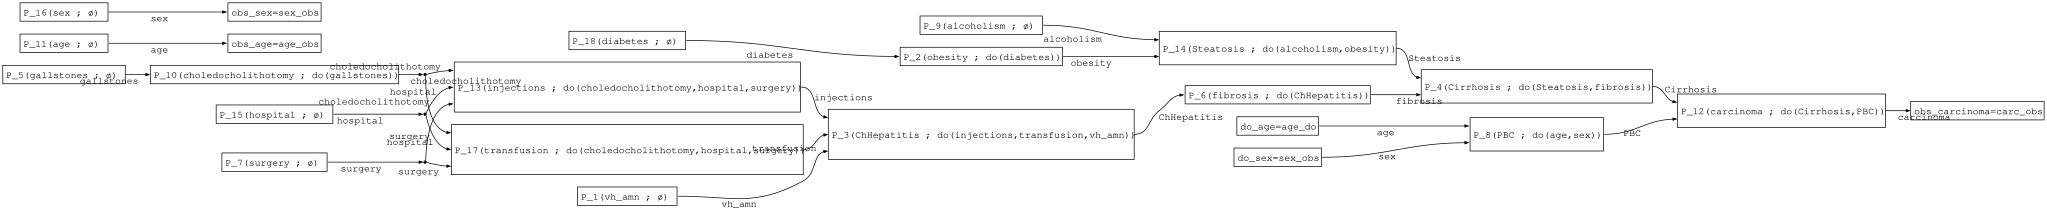

In [23]:
include(joinpath(pwd(), "simplify_cf.jl"))
include(joinpath(pwd(), "id_cf.jl"))

# Full-HEPAR2 three-world conditional example shared with comparisons/R_cfid/hepar2_example.r.
# Query: P(carcinoma_{do(age)} = carc_obs | age = age_obs, sex = sex_obs, pbc_{do(age)} = pbc_obs).
function run_hepar2_baseline(label, display_syms, queries; output_vars=String[])
    display_var = Set(display_syms)
    base_scm = graph_b_to_scm(hepar2_model; outputs=display_var)
    write_chyp("trace/HEPAR2/01_base_scm.chyp", base_scm; name="base_scm")
    wd = build_multiverse(base_scm, queries)
    write_chyp("trace/HEPAR2/02_multiverse.chyp", wd; name="multiverse")
    drop_discard_branches!(wd)
    write_chyp("trace/HEPAR2/03_simplify1.chyp", wd; name="s1")
    separate_sharp_effect_copy_maps!(wd)
    write_chyp("trace/HEPAR2/04_simplify2.chyp", wd; name="s2")
    merge_identical_deterministic_boxes(wd)
    write_chyp("trace/HEPAR2/05_simplify3.chyp", wd; name="s3")
    replace_fx_with_cx!(wd)
    write_chyp("trace/HEPAR2/06_simplify4.chyp", wd; name="s4")

    step3_blockers = sort!(unique(String(box(wd, b).value) for b in unabsorbed_lambda_boxes(wd)))
    println("== ", label, " ==")
    println("display vars: ", sort!(String.(collect(display_var))))
    println("step3 blockers: ", step3_blockers)

    id_cf_step4!(wd, display_var; verbose=false)
    println("STEP4_OK")

    result = id_cf_step5(wd; output_vars=output_vars, simplify=true, queries=queries, data=Step5DataConfig(mode=:conditional_queries), display=Step5DisplayConfig(symbols=Dict("age" => "age", "sex" => "sex", "pbc" => "pbc", "carcinoma" => "carcinoma"), value_rename=Dict("age_do" => "age")))
    println("raw formula: ", result.raw_tex)
    println("simplified formula: ", result.simplified_tex)
    println()
    return wd, result
end

hepar2_queries = [
    CounterfactualQuery(:Real, Dict{Symbol, Symbol}(), Dict(:age => :age_obs, :sex => :sex_obs), Symbol[]),
    CounterfactualQuery(:CF_pbc, Dict(:age => :age_do), Dict(:pbc => :pbc_obs), Symbol[]),
    CounterfactualQuery(:CF_carc, Dict(:age => :age_do), Dict(:carcinoma => :carc_obs), Symbol[]),
]

wd_hepar2_full, hepar2_result = run_hepar2_baseline(
    "full HEPAR2 three-world conditional example",
    [:age, :sex, :pbc, :carcinoma],
    hepar2_queries;
    output_vars=["carcinoma"],
)

draw(add_junctions(wd_hepar2_full))


## CFID comparison

The repository now keeps a single HEPAR2 comparison target at `comparisons/R_cfid/hepar2_example.r`.

That R script runs the same fraction-producing conditional query
`P(carcinoma_{do(age)} = carc_obs | age = age_obs, sex = sex_obs, pbc_{do(age)} = pbc_obs)` on the full HEPAR2 graph.

Run the next cell to print the `cfid` result for that conditional comparison target.

In [24]:
cfid_script = normpath(joinpath(pwd(), "..", "comparisons", "R_cfid", "hepar2_example.r"))
@assert isfile(cfid_script) "cfid script not found: $cfid_script"

cfid_output = read(`Rscript $cfid_script`, String)
println(cfid_output)


Identifiable? TRUE
Formula:
\frac{\sum_{alcoholism,gallstones,choledocholithotomy,hospital,injections,surgery,transfusion,chhepatitis,vh_amn,fibrosis,diabetes,obesity,steatosis,cirrhosis,sex^*} P(alcoholism)P(gallstones)P(choledocholithotomy|do(gallstones))P(hospital)P(injections|do(choledocholithotomy,hospital,surgery))P(surgery)P(transfusion|do(choledocholithotomy,hospital,surgery))P(chhepatitis|do(injections,transfusion,vh_amn))P(vh_amn)P(pbc|do(age,sex))P(fibrosis|do(chhepatitis))P(diabetes)P(obesity|do(diabetes))P(steatosis|do(alcoholism,obesity))P(cirrhosis|do(fibrosis,steatosis))P(carcinoma|do(cirrhosis,pbc))P(sex^*)}{\sum_{sex^*} P(sex^*)P(pbc|do(age,sex^*))} 



In [25]:
# Step4 audit for the selected full HEPAR2 baseline
# Assumes wd_hepar2_full was produced by the baseline runner above.

pbox_rows = []
for b in box_ids(wd_hepar2_full)
    nm = box(wd_hepar2_full, b).value
    if !(nm isa Symbol && startswith(String(nm), "P"))
        continue
    end
    f = parse_prob_box_name(nm)
    push!(pbox_rows, (
        box = String(nm),
        left = f === nothing ? String[] : f.left,
        do_vars = f === nothing ? String[] : f.dovars,
    ))
end

sort!(pbox_rows, by = x -> x.box)

println("Step4 probability boxes: ", length(pbox_rows))
println()
for row in pbox_rows
    println(row.box)
    println("  left   = ", row.left)
    println("  do     = ", row.do_vars)
end

all_factor_vars = sort(unique(vcat([row.left for row in pbox_rows]..., [row.do_vars for row in pbox_rows]...)))
fixed_obs_vars = String[]
fixed_do_vars = String[]
for b in box_ids(wd_hepar2_full)
    nm = box(wd_hepar2_full, b).value
    if nm isa Symbol
        if (p = parse_obs(nm)) !== nothing
            push!(fixed_obs_vars, p[1])
        elseif (p = parse_do(nm)) !== nothing
            push!(fixed_do_vars, p[1])
        end
    end
end

fixed_obs_vars = sort(unique(fixed_obs_vars))
fixed_do_vars = sort(unique(fixed_do_vars))
output_vars_full = String[]
latent_candidates = sort([v for v in all_factor_vars if !(v in output_vars_full) && !(v in fixed_obs_vars) && !(v in fixed_do_vars)])

println()
println("all vars appearing in Step4 factors = ", all_factor_vars)
println("fixed obs vars                     = ", fixed_obs_vars)
println("fixed do vars                      = ", fixed_do_vars)
println("step5 latent candidates            = ", latent_candidates)


Step4 probability boxes: 18

P_1(vh_amn ; ∅)
  left   = ["vh_amn"]
  do     = String[]
P_10(choledocholithotomy ; do(gallstones))
  left   = ["choledocholithotomy"]
  do     = ["gallstones"]
P_11(age ; ∅)
  left   = ["age"]
  do     = String[]
P_12(carcinoma ; do(Cirrhosis,PBC))
  left   = ["carcinoma"]
  do     = ["Cirrhosis", "PBC"]
P_13(injections ; do(choledocholithotomy,hospital,surgery))
  left   = ["injections"]
  do     = ["choledocholithotomy", "hospital", "surgery"]
P_14(Steatosis ; do(alcoholism,obesity))
  left   = ["Steatosis"]
  do     = ["alcoholism", "obesity"]
P_15(hospital ; ∅)
  left   = ["hospital"]
  do     = String[]
P_16(sex ; ∅)
  left   = ["sex"]
  do     = String[]
P_17(transfusion ; do(choledocholithotomy,hospital,surgery))
  left   = ["transfusion"]
  do     = ["choledocholithotomy", "hospital", "surgery"]
P_18(diabetes ; ∅)
  left   = ["diabetes"]
  do     = String[]
P_2(obesity ; do(diabetes))
  left   = ["obesity"]
  do     = ["diabetes"]
P_3(ChHepatitis 

## Daily commute counterfactual example (3 worlds)

Variables: `W` (weather), `T` (departure time), `M` (transport mode), `L` (lateness), `Y` (work performance).

Graph structure:

- Directed: `W -> T`, `W -> M`, `T -> L`, `M -> L`, `L -> Y`
- Bidirected (latent confounding): `T <-> Y`

Counterfactual query mapping:

- World 1: `do(T=t)`, target output `Y`
- World 2: factual observations `W=w`, `T=t'`
- World 3: auxiliary intervention `do(W=w)` and observation `M=m`


---- Step 4.1 on R-fragment #1 ----
  Fragment 1, var T, case1 = case1b_detected
  Fragment 1, var W, case2 = case2b_rewritten
  Fragment 1, var L, case2 = case2a_do_nothing
  Fragment 1, var Y, case1 = case1a_do_nothing
---- Step 4.1 on R-fragment #2 ----
  Fragment 2, var T, case2 = case2b_rewritten
  Fragment 2, var M, case2 = case2b_rewritten
  Fragment 2, var L, case1 = case1a_do_nothing
---- Step 4.1 on R-fragment #3 ----
  Fragment 3, var M, case1 = case1b_detected
  Fragment 3, var W, case2 = case2b_rewritten
---- Step 4.1 on R-fragment #4 ----
  Fragment 4, var W, case1 = case1b_detected
---- Step 4.2: collapsing R-fragment #1 ----
---- Step 4.2: collapsing R-fragment #2 ----
---- Step 4.2: collapsing R-fragment #3 ----
---- Step 4.2: collapsing R-fragment #4 ----
raw formula:
\frac{\sum_{l} P(w)P(t',y|do(w,l))P(l|do(m,t))P(m|do(w))}{\sum_{l} P(w)P(t'|do(w,l))P(l|do(m,t))P(m|do(w))}

simplified formula:
\frac{\sum_{l} P(w)P(t',y|do(w,l))P(l|do(m,t))P(m|do(w))}{\sum_{l} P(w)P(t

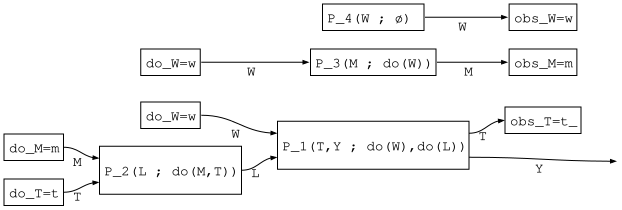

In [26]:
include(joinpath(pwd(), "admg_compile.jl"))
include(joinpath(pwd(), "simplify_cf.jl"))
include(joinpath(pwd(), "id_cf.jl"))
include(joinpath(pwd(), "utils.jl"))

commute_admg = ADMGModel(
    [
        :W => :T,
        :W => :M,
        :T => :L,
        :M => :L,
        :L => :Y,
    ],
    [
        :T => :Y,
    ],
)
display_var_commute = Set([:W, :T, :M, :L, :Y])
commute_model = rootify(commute_admg)
base_scm_commute = graph_b_to_scm(commute_model; outputs=display_var_commute)

q1 = CounterfactualQuery(
    :World1,
    Dict(:T => :t),
    Dict{Symbol, Symbol}(),
    [:Y],
)

q2 = CounterfactualQuery(
    :World2,
    Dict{Symbol, Symbol}(),
    Dict(:W => :w, :T => :t_),
    Symbol[],
)

q3 = CounterfactualQuery(
    :World3,
    Dict(:W => :w),
    Dict(:M => :m),
    Symbol[],
)
wd_commute = build_multiverse(base_scm_commute, [q1, q2, q3])
drop_discard_branches!(wd_commute)
merge_identical_deterministic_boxes(wd_commute)
replace_fx_with_cx!(wd_commute)

draw(add_junctions(wd_commute))

id_cf_step3_check!(wd_commute)
wd_commute = id_cf_step4!(wd_commute, Set([:W, :T, :M, :L, :Y]); verbose=true)

commute_res = id_cf_step5(
    wd_commute;
    output_vars=["Y"],
    simplify=true,
    rules=Step5RuleConfig(enabled=true, directed_edges=[("W","T"),("W","M"),("T","L"),("M","L"),("L","Y")]),
    display=Step5DisplayConfig(symbols=Dict("W"=>"w","T"=>"t","M"=>"m","L"=>"l","Y"=>"y"), value_rename=Dict("t_"=>"t'")),
    data=Step5DataConfig(mode=:interventions, mix_var="W", mix_sym="w^*", anchor_var="W", anchor_token="w"),
    queries=[q1,q2,q3],
)

println("raw formula:")
println(commute_res.raw_tex)
println()
println("simplified formula:")
println(commute_res.simplified_tex)
println()
println("data formula:")
println(commute_res.data_tex)

draw(add_junctions(wd_commute))


## R cfid (corresponding commute query)

Run the matching R/cfid script for the same commute ADMG and three-world query.

In [27]:
project_root = dirname(pwd())
r_script = joinpath(project_root, "comparisons", "R_cfid", "commute_example.r")
@assert isfile(r_script) "R cfid script not found: $r_script"

println("Running: Rscript ", r_script)
r_out = read(`Rscript $r_script`, String)
println(r_out)


Running: Rscript d:\CS\FYP_counterfactual\comparisons\R_cfid\commute_example.r
Identifiable? TRUE
Formula:
\frac{\sum_{l,w^*} P(m|do(w))P(l|do(m,t))P(y,t'|do(l,w))P(w^*)}{\sum_{w^*} P(w^*)P(t'|do(w^*))P(m|do(w^*))} 



In [28]:
res = identify_counterfactual(
    hepar2_model,
    hepar2_queries;
    display_syms=[:age, :sex, :pbc, :carcinoma],
    output_vars=["carcinoma"],
    data=Step5DataConfig(mode=:conditional_queries),
    display=Step5DisplayConfig(
        symbols=Dict("age"=>"age","sex"=>"sex","pbc"=>"pbc","carcinoma"=>"carcinoma"),
        value_rename=Dict("age_do"=>"age"),
    ),
    trace_dir="trace/HEPAR2_test",
)
println(res.identifiable)
println(res.data_tex)

true
\frac{\sum_{chhepatitis,cirrhosis,steatosis,alcoholism,choledocholithotomy,diabetes,fibrosis,gallstones,hospital,injections,obesity,surgery,transfusion,vh_amn,sex^*} P(vh_amn)P(obesity|do(diabetes))P(chhepatitis|do(injections,transfusion,vh_amn))P(cirrhosis|do(steatosis,fibrosis))P(gallstones)P(fibrosis|do(chhepatitis))P(surgery)P(pbc|do(age,sex))P(alcoholism)P(choledocholithotomy|do(gallstones))P(carcinoma|do(cirrhosis,pbc))P(injections|do(choledocholithotomy,hospital,surgery))P(steatosis|do(alcoholism,obesity))P(hospital)P(sex^*)P(transfusion|do(choledocholithotomy,hospital,surgery))P(diabetes)}{\sum_{sex^*} P(pbc|do(age,sex^*))P(sex^*)}


---- Step 4.1 on R-fragment #1 ----
  Fragment 1, var T, case1 = case1b_detected
  Fragment 1, var W, case2 = case2b_rewritten
  Fragment 1, var L, case2 = case2a_do_nothing
  Fragment 1, var Y, case1 = case1a_do_nothing
---- Step 4.1 on R-fragment #2 ----
  Fragment 2, var T, case2 = case2b_rewritten
  Fragment 2, var M, case2 = case2b_rewritten
  Fragment 2, var L, case1 = case1a_do_nothing
---- Step 4.1 on R-fragment #3 ----
  Fragment 3, var M, case1 = case1b_detected
  Fragment 3, var W, case2 = case2b_rewritten
---- Step 4.1 on R-fragment #4 ----
  Fragment 4, var W, case1 = case1b_detected
---- Step 4.2: collapsing R-fragment #1 ----
---- Step 4.2: collapsing R-fragment #2 ----
---- Step 4.2: collapsing R-fragment #3 ----
---- Step 4.2: collapsing R-fragment #4 ----
identifiable: true
failure_stage: nothing
error: nothing
raw formula:
\frac{\sum_{l} P(w)P(t',y|do(w,l))P(l|do(m,t))P(m|do(w))}{\sum_{l} P(w)P(t'|do(w,l))P(l|do(m,t))P(m|do(w))}
data formula:
\frac{\sum_{l,w^*} P(w^*

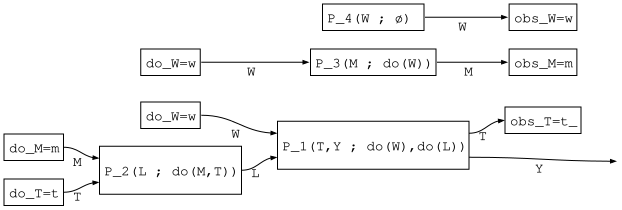

In [3]:
include(joinpath(pwd(), "admg_compile.jl"))
include(joinpath(pwd(), "simplify_cf.jl"))
include(joinpath(pwd(), "id_cf.jl"))
include(joinpath(pwd(), "utils.jl"))

commute_admg = ADMGModel(
    [
        :W => :T,
        :W => :M,
        :T => :L,
        :M => :L,
        :L => :Y,
    ],
    [
        :T => :Y,
    ],
)

q1 = CounterfactualQuery(
    :World1,
    Dict(:T => :t),
    Dict{Symbol, Symbol}(),
    [:Y],
)

q2 = CounterfactualQuery(
    :World2,
    Dict{Symbol, Symbol}(),
    Dict(:W => :w, :T => :t_),
    Symbol[],
)

q3 = CounterfactualQuery(
    :World3,
    Dict(:W => :w),
    Dict(:M => :m),
    Symbol[],
)

queries = [q1, q2, q3]

res = identify_counterfactual(
    commute_admg,
    queries;
    display_syms=[:W, :T, :M, :L, :Y],
    output_vars=["Y"],
    run_simplify=true,
    step4_verbose=true,
    rules=Step5RuleConfig(
        enabled=true,
        directed_edges=[("W","T"),("W","M"),("T","L"),("M","L"),("L","Y")]
    ),
    display=Step5DisplayConfig(
        symbols=Dict("W"=>"w","T"=>"t","M"=>"m","L"=>"l","Y"=>"y"),
        value_rename=Dict("t_"=>"t'")
    ),
    data=Step5DataConfig(
        mode=:interventions,
        mix_var="W",
        mix_sym="w^*",
        anchor_var="W",
        anchor_token="w"
    ),
    trace_dir="trace/daily_test",
    trace_prefix="commute",
)

println("identifiable: ", res.identifiable)
println("failure_stage: ", res.failure_stage)
println("error: ", res.error)
println("raw formula:")
println(res.raw_tex)
println("data formula:")
println(res.data_tex)


draw(add_junctions(res.wd))
